In [1]:
"""
create_dataset.py
=================
Genera un dataset sintético de tickets de soporte de telecomunicaciones en español.
Clases: Facturación | Problema Técnico | Baja del Servicio | Información Comercial

Ejecutar antes de entrenar los modelos.
Salida: 'data/tickets_train.csv', 'data/tickets_test.csv', 'data/response_pairs.csv'.
"""

import csv
import os
import random

random.seed (42)

# ─────────────────────────────────────────────
# 01. TICKETS DE CLASIFICACIÓN (4 clases)
# ─────────────────────────────────────────────

tickets_facturacion = [
    "Este mes me han cobrado 15 euros de más en mi factura. Quiero una explicación.",
    "No entiendo los cargos adicionales que aparecen en mi última factura.",
    "He recibido una factura de 200 euros cuando siempre pago 60. ¿Qué ha pasado?",
    "Quiero reclamar un cargo que no reconozco. Nunca contraté ese servicio adicional.",
    "Mi domiciliación bancaria ha fallado y ahora me cobran una penalización. No es justo.",
    "Llevo dos meses esperando la devolución de un cobro duplicado.",
    "La factura del mes de diciembre tiene un cargo por TV que no tengo contratado.",
    "¿Por qué me han subido la tarifa sin avisarme? Mi contrato dice que el precio es fijo.",
    "Necesito una copia de todas mis facturas del último año para mi declaración de la renta.",
    "Me han cortado el servicio por supuesto impago pero yo pagué hace dos semanas.",
    "He cambiado de cuenta bancaria y necesito actualizar la domiciliación.",
    "El cargo de roaming en mi última factura es desproporcionado. Solo estuve dos días fuera.",
    "Quiero saber exactamente qué incluye cada partida de mi factura.",
    "Mi factura ha subido 20 euros desde enero sin que yo haya pedido nada nuevo.",
    "¿Podéis enviarme la factura por correo electrónico en lugar de en papel?",
    "Me han cobrado dos veces el mismo mes. Necesito que me devuelvan el segundo cargo.",
    "La factura no refleja el descuento por fidelidad que me prometieron al renovar.",
    "Tengo un recibo sin concepto claro por valor de 9,99 euros. ¿Qué es?",
    "Quiero fraccionar el pago de mi factura de este mes porque es más alta de lo habitual.",
    "Necesito un certificado de estar al corriente de pago para mi empresa.",
    "Me han mandado una carta de impago pero mi cuenta tiene saldo suficiente.",
    "La factura no incluye el IVA desglosado. Necesito eso para la contabilidad de mi negocio.",
    "¿Cómo puedo cambiar la fecha de cargo mensual? El día 1 no me viene bien.",
    "Contraté una promoción de 3 meses gratis y en el segundo mes ya me están cobrando.",
    "Hay un cargo de instalación que me dijeron que sería gratuito.",
    "Quiero una factura pro forma para presentar a mi empresa antes del pago.",
    "El precio de mi tarifa ha cambiado pero nadie me lo ha comunicado oficialmente.",
    "Necesito que me envíen todas las facturas de los últimos 3 años.",
    "Me han dado de alta un seguro de dispositivo que yo no pedí y me lo están cobrando.",
    "¿Cuándo se emite la próxima factura? Necesito planificar mis gastos.",
]

tickets_problema_tecnico = [
    "Llevo tres días sin internet. He reiniciado el router y nada.",
    "Mi conexión a internet va muy lenta. Contrato 600 Mb y recibo 20 Mb.",
    "El router parpadea en rojo continuamente desde ayer por la tarde.",
    "No tengo cobertura móvil en mi domicilio desde la semana pasada.",
    "La fibra óptica se cae varias veces al día durante unos minutos.",
    "No puedo hacer llamadas desde mi línea fija. Escucho un pitido continuo.",
    "La televisión de pago no carga ningún canal. La pantalla se queda negra.",
    "Mi tarifa de datos del móvil no funciona. Tengo saldo pero no conecta.",
    "El WiFi funciona en el salón pero no llega a las habitaciones.",
    "Desde que instalaron la fibra, el teléfono fijo no tiene tono.",
    "La velocidad baja drásticamente por las noches, entre las 21h y las 23h.",
    "He intentado configurar el correo corporativo y no consigo conectarme al servidor.",
    "El servicio de televisión en streaming falla constantemente con error 503.",
    "No puedo recibir llamadas entrantes en el móvil aunque sí puedo llamar.",
    "El técnico vino ayer pero el problema sigue igual. Quiero que vuelvan.",
    "Mi router no emite señal WiFi pero la luz verde está encendida.",
    "La conexión se cae exactamente cada hora. Parece algo automático.",
    "Tengo contratado el servicio de llamadas ilimitadas pero me está cobrando las llamadas.",
    "No puedo enviar mensajes MMS desde hace dos semanas.",
    "El decodificador de televisión se reinicia solo varias veces al día.",
    "Hay mucho ruido en la línea cuando hablo por teléfono.",
    "Mi número de teléfono no aparece cuando llamo a otras personas.",
    "No puedo acceder a mi correo de empresa desde el móvil con datos.",
    "La señal 4G en mi barrio ha empeorado muchísimo en el último mes.",
    "El servicio de VoIP que contraté no funciona con mi centralita.",
    "Tengo problemas con la portabilidad. Mi número no está funcionando bien.",
    "La app de gestión de mi cuenta no carga desde la última actualización.",
    "El WiFi de invitados que configuré ha dejado de funcionar.",
    "Mi línea móvil ha sido suspendida sin previo aviso y tengo todos los pagos al día.",
    "El técnico dijo que el problema era de la red exterior pero sigue sin resolverse.",
]

tickets_baja_servicio = [
    "Quiero darme de baja de todos los servicios contratados lo antes posible.",
    "Deseo cancelar mi línea móvil. ¿Cuál es el procedimiento?",
    "Quiero cancelar el contrato de fibra. Me voy a vivir al extranjero.",
    "Necesito tramitar la baja del servicio de televisión que tengo contratado.",
    "¿Cuánto tiempo tardan en tramitar una baja? Lo necesito para el mes que viene.",
    "Quiero portar mi número a otra operadora. ¿Qué tengo que hacer?",
    "Me han renovado el contrato automáticamente y quiero cancelarlo sin penalización.",
    "Solicito la baja inmediata del servicio por incumplimiento del contrato.",
    "¿Tiene algún coste dar de baja la línea secundaria que tenemos?",
    "Quiero cancelar el servicio pero me han dicho que tengo permanencia hasta junio.",
    "He fallecido un familiar que era titular de la línea. ¿Cómo gestiono la baja?",
    "Quiero darme de baja pero primero necesito saber si hay penalización.",
    "He encontrado una oferta mejor en otra compañía y quiero cancelar mi contrato.",
    "Necesito la baja por escrito. ¿Podéis enviarme el formulario por email?",
    "¿Puedo dar de baja solo la televisión y mantener la fibra?",
    "Quiero tramitar la baja pero el 900 no me funciona. ¿Hay otra forma de hacerlo?",
    "Me trasladé hace dos meses y en la nueva dirección no tenéis cobertura. Quiero la baja.",
    "El servicio lleva meses sin funcionar bien y quiero resolver el contrato.",
    "¿Cuándo se hace efectiva la baja si la solicito hoy?",
    "Quiero cancelar el servicio de alarma conectado que tenía con vosotros.",
    "Necesito certificado de baja para presentar a la nueva operadora.",
    "¿La baja se puede hacer online o necesito ir a una tienda?",
    "Quiero cancelar el seguro del terminal que me metieron en el contrato.",
    "Me jubilo y ya no necesito las líneas de empresa. ¿Cómo las cancelo todas?",
    "¿Qué pasa con el router si doy de baja la fibra? ¿Tengo que devolverlo?",
    "La promotora del piso donde vivo ya tiene fibra de vuestra competencia instalada.",
    "He cambiado de trabajo y mi empresa ya no necesita este servicio.",
    "Quiero la baja retroactiva al mes pasado, cuando ya no usaba el servicio.",
    "¿Puedo solicitar la baja sin llamar por teléfono? No me gusta hablar con operadores.",
    "Quiero cancelar todo antes de que acabe el mes para no pagar la siguiente factura.",
]

tickets_info_comercial = [
    "¿Qué tarifas tienen disponibles para fibra más móvil? Somos dos personas en casa.",
    "Quiero saber si tienen alguna promoción para nuevos clientes.",
    "¿Tienen alguna oferta para estudiantes universitarios?",
    "¿Cuánto cuesta añadir una línea móvil adicional a mi contrato de fibra?",
    "Me gustaría saber qué canales incluye el paquete básico de televisión.",
    "¿Tienen cobertura de fibra en mi nueva dirección? Me acabo de mudar.",
    "¿Cuál es la diferencia entre la tarifa BÁSICA y la PREMIUM?",
    "¿Ofrecen descuentos para autónomos o pymes?",
    "Quiero contratar la fibra. ¿Cuánto tarda la instalación desde que lo solicito?",
    "¿Tienen algún plan con llamadas internacionales incluidas?",
    "¿Qué velocidad de subida ofrece el plan de 600 Mb?",
    "¿Puedo contratar solo el móvil sin la fibra?",
    "¿Tienen ofertas de Black Friday o rebajas de verano próximamente?",
    "Me interesa el paquete familiar. ¿Cuántas líneas móviles incluye?",
    "¿Tienen terminales móviles en cuotas? Me gustaría renovar mi teléfono.",
    "¿Cuál es la cobertura 5G en mi ciudad?",
    "¿Ofrecen fibra simétrica para trabajar desde casa con videollamadas?",
    "¿Hay algún período de prueba sin permanencia?",
    "¿Qué pasa si me voy al extranjero? ¿Tienen roaming europeo incluido?",
    "¿Puedo ver los canales de televisión fuera de España con vuestra app?",
    "¿Cuál es el precio final con IVA de la tarifa más popular?",
    "¿Ofrecen servicio de telefonía fija o solo móvil e internet?",
    "Quiero información sobre vuestros planes para empresas de menos de 10 empleados.",
    "¿Tienen algún programa de referidos o de recomendación para clientes?",
    "¿El precio de las tarifas es fijo o puede cambiar durante el contrato?",
    "¿Qué incluye exactamente el seguro del dispositivo móvil?",
    "¿Pueden instalar fibra en un edificio antiguo sin canalización?",
    "¿Cuánto tiempo dura la permanencia en los nuevos contratos?",
    "¿Tienen atención al cliente en castellano y catalán?",
    "¿Cómo funciona la portabilidad si vengo de otra operadora?",
]

# ─────────────────────────────────────────────
# 02. CREAR DATASET COMPLETO
# ─────────────────────────────────────────────

all_tickets = []
for t in tickets_facturacion:
    all_tickets.append ({"text": t, "label": "Facturación"})
for t in tickets_problema_tecnico:
    all_tickets.append ({"text": t, "label": "Problema Técnico"})
for t in tickets_baja_servicio:
    all_tickets.append ({"text": t, "label": "Baja del Servicio"})
for t in tickets_info_comercial:
    all_tickets.append ({"text": t, "label": "Información Comercial"})

random.shuffle(all_tickets)

# Split 80/20
split = int(len(all_tickets) * 0.8)
train_data = all_tickets[:split]
test_data = all_tickets[split:]

# ─────────────────────────────────────────────
# 03. PARES (Ticket, Respuesta) PARA EL DECODER
# ─────────────────────────────────────────────

response_pairs = [
    # Información Comercial
    {
        "input": "¿Qué tarifas tienen disponibles para fibra más móvil? Somos dos personas en casa.",
        "output": "Hola, gracias por contactar con nosotros. Tenemos varias opciones perfectas para dos personas: el paquete DÚO incluye fibra de 300 Mb + 2 líneas móviles con 20 GB cada una por 49,99€/mes. Si queréis más velocidad, el paquete DÚO PLUS ofrece 600 Mb + 2 líneas con datos ilimitados por 69,99€/mes. Ambos sin permanencia el primer año. ¿Quieres que te llame un asesor para ayudarte a elegir?"
    },
    {
        "input": "¿Tienen alguna promoción para nuevos clientes?",
        "output": "¡Bienvenido! Actualmente tenemos una promoción especial: los tres primeros meses de fibra gratis al contratar cualquier paquete combinado. Además, si traes tu número de otra operadora, te regalamos el terminal de última generación con cuota cero. La oferta es válida hasta fin de mes. ¿Te gustaría que un asesor te explicara los detalles sin compromiso?"
    },
    {
        "input": "¿Cuánto cuesta añadir una línea móvil adicional a mi contrato de fibra?",
        "output": "Añadir una línea adicional a tu contrato de fibra tiene un coste de 9,99€/mes para 10 GB de datos o 14,99€/mes para datos ilimitados. Si ya tienes un paquete DÚO o superior, el precio es todavía mejor. Puedes gestionarlo directamente desde tu área de cliente o llamándonos al 1234. ¿Necesitas más información sobre alguna de las opciones?"
    },
    {
        "input": "¿Tienen cobertura de fibra en mi nueva dirección? Me acabo de mudar.",
        "output": "¡Enhorabuena por tu mudanza! Para verificar la cobertura en tu nueva dirección, puedes usar nuestro comprobador online en www.operadora.es/cobertura o indicarme tu dirección completa y lo compruebo al momento. Si hay cobertura, podemos gestionar el traslado del servicio sin coste adicional. ¿Me indicas la dirección?"
    },
    {
        "input": "¿Hay algún período de prueba sin permanencia?",
        "output": "Sí, todos nuestros nuevos contratos incluyen 30 días de prueba sin permanencia. Si en ese período no estás satisfecho, puedes cancelar sin coste alguno. Pasado ese plazo, la permanencia estándar es de 12 meses. ¿Quieres que procedamos con el alta de alguno de nuestros paquetes?"
    },
    {
        "input": "¿Tienen planes para empresas de menos de 10 empleados?",
        "output": "¡Por supuesto! Nuestro plan PYME ESENCIAL está diseñado para negocios de hasta 10 empleados e incluye fibra simétrica de 600 Mb, hasta 5 líneas móviles con datos ilimitados, centralita virtual y soporte técnico prioritario por 89,99€/mes. También incluimos el alta y la instalación gratuitas. ¿Te envío un folleto informativo detallado a tu correo?"
    },
    {
        "input": "¿Cuál es la cobertura 5G en mi ciudad?",
        "output": "Nuestra red 5G ya cubre el 75% de las capitales de provincia y seguimos ampliando. Para ver la cobertura exacta en tu ciudad, puedes consultar el mapa interactivo en nuestra web o indicarme tu localidad y te confirmo si hay cobertura 5G en tu zona. ¿Me dices dónde vives?"
    },
    {
        "input": "¿El precio de las tarifas es fijo o puede cambiar durante el contrato?",
        "output": "El precio que acordamos en el contrato es el que pagas durante toda la permanencia, sin sorpresas. Una vez finalizado el período de permanencia, te avisamos con 30 días de antelación de cualquier revisión de precio, dándote la opción de renovar en las nuevas condiciones o cancelar sin penalización. La transparencia es nuestra prioridad."
    },
    # Problema técnico
    {
        "input": "Llevo tres días sin internet. He reiniciado el router y nada.",
        "output": "Lamentamos los inconvenientes. Hemos verificado tu línea y detectamos una posible incidencia en el nodo de tu zona. Nuestros técnicos están trabajando en ello y esperamos tenerlo resuelto en las próximas 24 horas. Si transcurrido ese plazo sigues sin conexión, abriremos una visita técnica en domicilio sin coste. Te mantendremos informado por SMS. ¿Tienes alguna otra consulta mientras tanto?"
    },
    {
        "input": "Mi conexión a internet va muy lenta. Contrato 600 Mb y recibo 20 Mb.",
        "output": "Entendemos tu frustración. Lo primero es realizar un diagnóstico remoto: ¿puedes conectarte al router directamente con cable y hacer una prueba de velocidad en fast.com? Si la velocidad también es baja con cable, abriremos una incidencia técnica prioritaria. Si con cable va bien, el problema puede estar en la configuración WiFi, y podemos guiarte para optimizarla. ¿Qué resultado obtienes con cable?"
    },
    {
        "input": "El router parpadea en rojo continuamente desde ayer por la tarde.",
        "output": "La luz roja continua en el router indica que no hay señal de red desde nuestra central hasta tu domicilio. Esto puede deberse a una avería en la línea exterior o en el nodo de tu zona. Ya hemos creado una incidencia con número REF-20240127 y nuestro equipo técnico la está atendiendo. Si en 48 horas no se resuelve, programaremos una visita de técnico. ¿Vives en una vivienda unifamiliar o en un bloque de pisos?"
    },
    {
        "input": "No tengo cobertura móvil en mi domicilio desde la semana pasada.",
        "output": "Sentimos los problemas con la cobertura. Hemos consultado el estado de las antenas de tu zona y efectivamente hay una mejora en curso en la red que puede estar afectando temporalmente a la señal. Estimamos que se normalizará en 48-72 horas. Como solución provisional, puedes activar el WiFi Calling en tu móvil para hacer llamadas a través de internet. ¿Necesitas ayuda para configurarlo?"
    },
    {
        "input": "La fibra óptica se cae varias veces al día durante unos minutos.",
        "output": "Una conexión que cae de forma intermitente suele indicar inestabilidad en la línea o en el splitter del edificio. Para diagnosticarlo necesitamos revisar los logs de tu router. Por favor, accede a 192.168.1.1 desde tu navegador, ve a 'Diagnóstico' y anota el número de reconexiones de las últimas 24 horas. Con ese dato podemos determinar si es necesaria una visita técnica. ¿Puedes acceder al panel del router?"
    },
    {
        "input": "No puedo hacer llamadas desde mi línea fija. Escucho un pitido continuo.",
        "output": "Un pitido continuo en la línea fija puede indicar que el servicio está temporalmente suspendido o que hay una avería en la centralita. Hemos comprobado tu cuenta y está activa y al corriente de pago, por lo que es una incidencia técnica. Hemos abierto la avería con número AVE-00458. Nuestro equipo técnico la atenderá en un máximo de 24 horas laborables. ¿Tienes teléfono móvil disponible mientras tanto?"
    },
    {
        "input": "La velocidad baja drásticamente por las noches, entre las 21h y las 23h.",
        "output": "Esta saturación en horas pico es un problema que estamos resolviendo con ampliación de capacidad en tu nodo. Mientras tanto, puedes configurar QoS en tu router para priorizar el tráfico importante, o conectarte a la banda de 5 GHz del WiFi en lugar de 2,4 GHz, que es más rápida. Te damos de alta en nuestro programa de monitorización para analizar el problema en detalle. ¿Te parece bien?"
    },
    {
        "input": "Mi tarifa de datos del móvil no funciona. Tengo saldo pero no conecta.",
        "output": "Vamos a verificar la configuración de datos de tu línea. Primero, comprueba que los datos móviles estén activados en los ajustes de tu teléfono y que el APN esté configurado correctamente (APN: internet). Si todo está correcto, prueba a reiniciar el teléfono. Si sigue sin funcionar, le hacemos un refresco remoto a tu línea desde nuestros sistemas, lo que suele resolver el problema en 5 minutos. ¿Probamos el refresco?"
    },
]

# ─────────────────────────────────────────────
# 04. GUARDAR FICHEROS CSV
# ─────────────────────────────────────────────

os.makedirs ("data", exist_ok = True)

for filename, data in [("data/tickets_train.csv", train_data), ("data/tickets_test.csv", test_data)]:
    with open (filename, "w", newline = "", encoding = "utf-8") as f:
        writer = csv.DictWriter (f, fieldnames = ["text", "label"])
        writer.writeheader()
        writer.writerows (data)

# Pares de Respuesta para el Decoder
with open ("data/response_pairs.csv", "w", newline = "", encoding = "utf-8") as f:
    writer = csv.DictWriter (f, fieldnames = ["input", "output"])
    writer.writeheader()
    writer.writerows (response_pairs)

print (f"Dataset Generado Correctamente.")
print (f"- Entrenamiento: {len(train_data)} Ejemplos  →  data/tickets_train.csv")
print (f"- Test: {len(test_data)} Ejemplos  →  data/tickets_test.csv")
print (f"- Pares Respuesta: {len(response_pairs)} Pares → data/response_pairs.csv")
print()
print ("Distribución en Train:")
from collections import Counter
counts = Counter (d ["label"] for d in train_data)
for label, count in sorted (counts.items()):
    print (f"{label}: {count} Ejemplos")

Dataset Generado Correctamente.
- Entrenamiento: 96 Ejemplos  →  data/tickets_train.csv
- Test: 24 Ejemplos  →  data/tickets_test.csv
- Pares Respuesta: 16 Pares → data/response_pairs.csv

Distribución en Train:
Baja del Servicio: 24 Ejemplos
Facturación: 21 Ejemplos
Información Comercial: 24 Ejemplos
Problema Técnico: 27 Ejemplos


In [2]:
!pip install transformers datasets scikit-learn matplotlib seaborn torch accelerate --quiet

Imports OK
GPU Disponible: True
GPU: Tesla T4
Datos Cargados: 96 Train / 24 Test


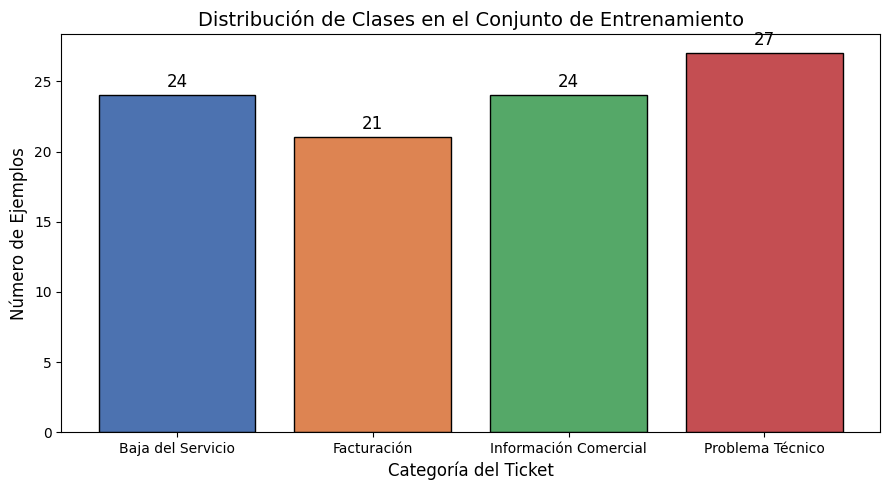

Gráfico Guardado en 'outputs/class_distribution.png'


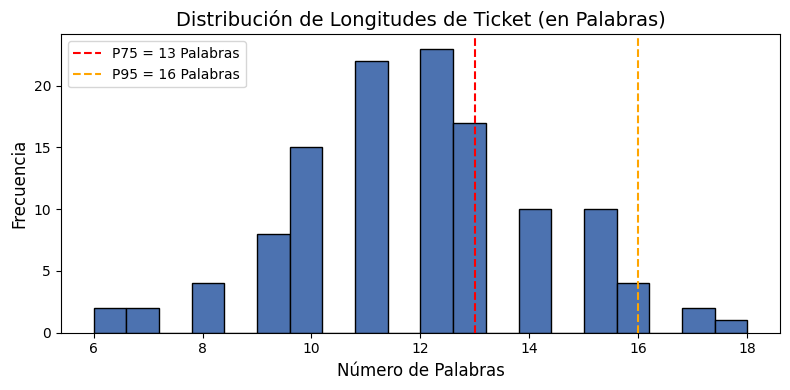

Longitud Media: 11.9 Palabras
Longitud Máxima: 18 Palabras
P75: 13 Palabras → Elegimos max_length = 64
Gráfico Guardado en 'outputs/length_distribution.png'


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/310 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Entrenamiento Completado.



RESULTADOS EN TEST
                       precision    recall  f1-score   support

          Facturación       1.00      0.78      0.88         9
     Problema Técnico       0.75      1.00      0.86         3
    Baja del Servicio       0.80      0.67      0.73         6
Información Comercial       0.75      1.00      0.86         6

             accuracy                           0.83        24
            macro avg       0.82      0.86      0.83        24
         weighted avg       0.86      0.83      0.83        24

F1 (weighted): 0.8314
Accuracy: 0.8333


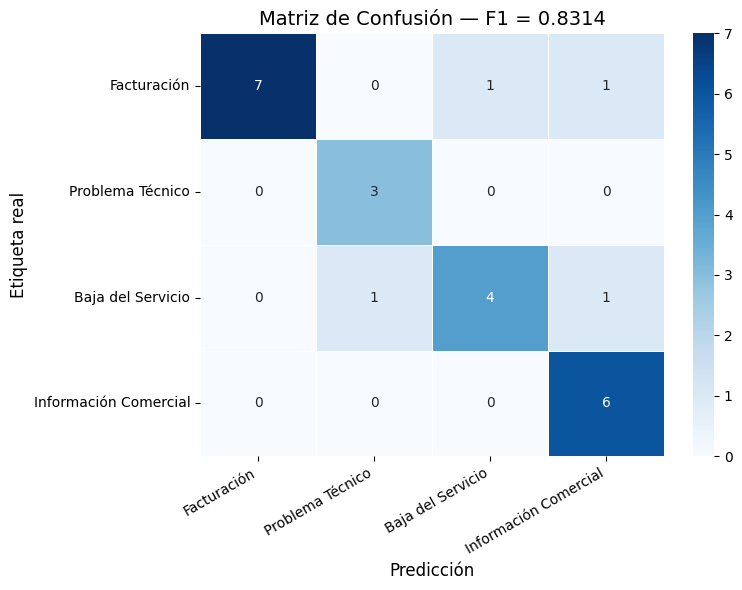

Matriz Guardada en 'outputs/confusion_matrix.png'


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo Guardado en 'outputs/encoder_model/'

Prueba de Inferencia:
Texto: ¿Cuánto cuesta el paquete de fibra más móvil para dos person...
→ Categoría: Información Comercial

Texto: Llevo dos días sin internet y ya he reiniciado el router var...
→ Categoría: Problema Técnico

Texto: Quiero darme de baja de todos los servicios....
→ Categoría: Baja del Servicio

Texto: En mi última factura hay un cargo que no reconozco....
→ Categoría: Facturación



In [3]:
"""
encoder_training.py
==============================================================
Tarea: Clasificación de Tickets de Soporte
Modelo Base: dccuchile/bert-base-spanish-wwm-uncased
Clases: Facturación | Problema Técnico | Baja del Servicio | Información Comercial

Ejecuta primero 'create_dataset.py' para generar los CSVs.
"""

# ══════════════════════════════════════════════
# CELDA 01 — Instalación de Dependencias
# ══════════════════════════════════════════════
!pip install transformers datasets scikit-learn matplotlib seaborn torch --quiet

# ══════════════════════════════════════════════
# CELDA 02 — Imports
# ══════════════════════════════════════════════
import csv
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
)

SEED = 42
random.seed (SEED)
np.random.seed (SEED)
torch.manual_seed (SEED)

LABEL2ID = {
    "Facturación": 0,
    "Problema Técnico": 1,
    "Baja del Servicio": 2,
    "Información Comercial": 3,
}

ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = len (LABEL2ID)

print ("Imports OK")
print (f"GPU Disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print (f"GPU: {torch.cuda.get_device_name (0)}")

# ══════════════════════════════════════════════
# CELDA 03 — Cargar Datos
# ══════════════════════════════════════════════
def load_csv (path):
    with open (path, encoding = "utf-8") as f:
        reader = csv.DictReader (f)
        return list (reader)

train_raw = load_csv ("data/tickets_train.csv")
test_raw = load_csv ("data/tickets_test.csv")

train_texts = [r ["text"]  for r in train_raw]
train_labels = [LABEL2ID [r ["label"]] for r in train_raw]
test_texts = [r ["text"]  for r in test_raw]
test_labels = [LABEL2ID [r ["label"]] for r in test_raw]

print (f"Datos Cargados: {len (train_texts)} Train / {len (test_texts)} Test")

# ══════════════════════════════════════════════
# CELDA 04 — EDA: Distribución de Clases
# ══════════════════════════════════════════════
from collections import Counter

train_counts = Counter (r ["label"] for r in train_raw)
labels_sorted = sorted (train_counts.keys())
counts_sorted = [train_counts [l] for l in labels_sorted]

fig, ax = plt.subplots (figsize = (9, 5))
bars = ax.bar (labels_sorted, counts_sorted,
               color = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"], edgecolor = "black")
ax.set_title ("Distribución de Clases en el Conjunto de Entrenamiento", fontsize = 14)
ax.set_xlabel ("Categoría del Ticket", fontsize = 12)
ax.set_ylabel ("Número de Ejemplos", fontsize = 12)
for bar, count in zip (bars, counts_sorted):
    ax.text (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             str (count), ha = "center", va = "bottom", fontsize = 12)
plt.tight_layout()
os.makedirs ("outputs", exist_ok = True)
plt.savefig ("outputs/class_distribution.png", dpi = 150)
plt.show()
print ("Gráfico Guardado en 'outputs/class_distribution.png'")

# ══════════════════════════════════════════════
# CELDA 05 — EDA: Histograma de Longitudes de Texto
# ══════════════════════════════════════════════
all_lengths = [len (t.split()) for t in train_texts + test_texts]

fig, ax = plt.subplots (figsize = (8, 4))
ax.hist (all_lengths, bins = 20, color = "#4C72B0", edgecolor = "black")
ax.axvline (np.percentile (all_lengths, 75), color = "red", linestyle = "--",
            label = f"P75 = {int (np.percentile (all_lengths, 75))} Palabras")
ax.axvline (np.percentile (all_lengths, 95), color = "orange", linestyle = "--",
            label = f"P95 = {int (np.percentile (all_lengths, 95))} Palabras")
ax.set_title ("Distribución de Longitudes de Ticket (en Palabras)", fontsize = 14)
ax.set_xlabel ("Número de Palabras", fontsize = 12)
ax.set_ylabel ("Frecuencia", fontsize = 12)
ax.legend()
plt.tight_layout()
plt.savefig ("outputs/length_distribution.png", dpi = 150)
plt.show()

print (f"Longitud Media: {np.mean(all_lengths):.1f} Palabras")
print (f"Longitud Máxima: {max(all_lengths)} Palabras")
print (f"P75: {int (np.percentile (all_lengths, 75))} Palabras → Elegimos max_length = 64")
print ("Gráfico Guardado en 'outputs/length_distribution.png'")

# ══════════════════════════════════════════════
# CELDA 06 — Tokenización
# ══════════════════════════════════════════════
MODEL_NAME = "dccuchile/bert-base-spanish-wwm-uncased"
MAX_LENGTH = 64  # Justificado por el Histograma: P95 < 50 palabras

tokenizer = AutoTokenizer.from_pretrained (MODEL_NAME)

class TicketDataset (Dataset):
    def __init__ (self, texts, labels):
        self.encodings = tokenizer (
            texts,
            truncation = True,
            padding = "max_length",
            max_length = MAX_LENGTH,
            return_tensors = "pt",
        )

        self.labels = labels

    def __len__ (self):
        return len (self.labels)

    def __getitem__ (self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item ["labels"] = torch.tensor (self.labels [idx])
        return item

train_dataset = TicketDataset (train_texts, train_labels)
test_dataset  = TicketDataset (test_texts,  test_labels)
print (f"Tokenización Completa. max_length = {MAX_LENGTH}")

# ══════════════════════════════════════════════
# CELDA 07 — Modelo y Métricas
# ══════════════════════════════════════════════
model = AutoModelForSequenceClassification.from_pretrained (
    MODEL_NAME,
    num_labels = NUM_LABELS,
    id2label = ID2LABEL,
    label2id = LABEL2ID,
)

print (f"Modelo Cargado: {MODEL_NAME}")

def compute_metrics (eval_pred):
    logits, labels = eval_pred
    preds = np.argmax (logits, axis = -1)
    f1  = f1_score (labels, preds, average = "weighted")
    acc = accuracy_score (labels, preds)
    return {"f1": f1, "accuracy": acc}

# ══════════════════════════════════════════════
# CELDA 08 — Entrenamiento
# ══════════════════════════════════════════════
training_args = TrainingArguments (
    output_dir = "outputs/encoder_checkpoints",
    num_train_epochs = 5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    warmup_steps = 20,
    weight_decay = 0.01,
    learning_rate = 2e-5,
    eval_strategy = "epoch",
    save_strategy = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model = "f1",
    logging_dir = "outputs/logs",
    logging_steps = 10,
    report_to = "none",
    seed = SEED,
)

trainer = Trainer (
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = test_dataset,
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback (early_stopping_patience = 2)],
)

print ("Iniciando Entrenamiento...")
trainer.train()
print ("Entrenamiento Completado.")

# ══════════════════════════════════════════════
# CELDA 09 — Evaluación en Test
# ══════════════════════════════════════════════
predictions = trainer.predict (test_dataset)
preds = np.argmax (predictions.predictions, axis = -1)
true_labels = [t ["labels"].item() for t in test_dataset]

print ("\n" + "=" * 60)
print ("RESULTADOS EN TEST")
print ("=" * 60)
print (classification_report (
       true_labels, preds,
       target_names = list (LABEL2ID.keys())
))

f1_final = f1_score (true_labels, preds, average = "weighted")
acc_final = accuracy_score (true_labels, preds)
print (f"F1 (weighted): {f1_final:.4f}")
print (f"Accuracy: {acc_final:.4f}")

# ══════════════════════════════════════════════
# CELDA 10 — Matriz de Confusión
# ══════════════════════════════════════════════
cm = confusion_matrix (true_labels, preds)
label_names = list (LABEL2ID.keys())

fig, ax = plt.subplots (figsize = (8, 6))
sns.heatmap (cm, annot=True, fmt="d", cmap="Blues",
             xticklabels = label_names, yticklabels = label_names,
             ax = ax, linewidths = 0.5)
ax.set_xlabel ("Predicción", fontsize = 12)
ax.set_ylabel ("Etiqueta real", fontsize = 12)
ax.set_title (f"Matriz de Confusión — F1 = {f1_final:.4f}", fontsize = 14)
plt.xticks (rotation = 30, ha = "right")
plt.tight_layout()
plt.savefig ("outputs/confusion_matrix.png", dpi = 150)
plt.show()
print ("Matriz Guardada en 'outputs/confusion_matrix.png'")

# ══════════════════════════════════════════════
# CELDA 11 — Guardar Modelo Fine-Tuneado
# ══════════════════════════════════════════════
SAVE_PATH = "outputs/encoder_model"
model.save_pretrained (SAVE_PATH)
tokenizer.save_pretrained (SAVE_PATH)
print (f"Modelo Guardado en 'outputs/encoder_model/'")

# ══════════════════════════════════════════════
# CELDA 12 — Prueba Rápida de Inferencia
# ══════════════════════════════════════════════
def predict_category (text):
    model.eval()
    inputs = tokenizer (text, return_tensors = "pt", truncation = True,
                        padding = True, max_length = MAX_LENGTH)
    inputs = {k: v.to (model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model (**inputs)
    pred_id = outputs.logits.argmax (-1).item()
    return ID2LABEL [pred_id]

test_samples = [
    "¿Cuánto cuesta el paquete de fibra más móvil para dos personas?",
    "Llevo dos días sin internet y ya he reiniciado el router varias veces.",
    "Quiero darme de baja de todos los servicios.",
    "En mi última factura hay un cargo que no reconozco.",
]

print ("\nPrueba de Inferencia:")
for sample in test_samples:
    print (f"Texto: {sample [:60]}...")
    print (f"→ Categoría: {predict_category (sample)}\n")

In [4]:
"""
decoder_training.py
=============================================================
Tarea: Generación de Respuestas Automáticas a Tickets de Soporte
Modelo base: datificate/gpt2-small-spanish  (GPT-2 Small en Español)
Formato: Instrucción → Respuesta (Instruction Tuning Ligero)

Asegúrate de haber ejecutado 'create_dataset.py' antes.
Necesitas al menos ~4 GB de GPU RAM (T4 de Colab Vale Perfectamente).
"""

# ══════════════════════════════════════════════
# CELDA 01 — Instalación
# ══════════════════════════════════════════════
!pip install transformers datasets torch accelerate --quiet

# ══════════════════════════════════════════════
# CELDA 02 — Imports
# ══════════════════════════════════════════════
import os
import csv
import random
import torch
import numpy as np
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
)

from torch.utils.data import Dataset

SEED = 42
random.seed (SEED)
torch.manual_seed (SEED)

print ("Imports OK")
print (f"GPU Disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print (f"GPU: {torch.cuda.get_device_name (0)}")

# ══════════════════════════════════════════════
# CELDA 03 — Definir Formato del Prompt
# ══════════════════════════════════════════════
# Usamos un Formato Sencillo de Instrucción → Respuesta
PROMPT_TEMPLATE = """### Ticket de Soporte:
{ticket}

### Respuesta del Agente:
{respuesta}"""

# Ejemplo Real del Formato
ejemplo = PROMPT_TEMPLATE.format (
    ticket = "¿Qué tarifas tienen disponibles para fibra más móvil?",
    respuesta = "Hola, tenemos varias opciones: el paquete DÚO incluye fibra 300Mb + 2 líneas por 49,99€/mes."
)
print ("Ejemplo de Formato:\n")
print (ejemplo)

# ══════════════════════════════════════════════
# CELDA 04 — Cargar Datos de Respuesta
# ══════════════════════════════════════════════
def load_response_pairs (path):
    with open (path, encoding = "utf-8") as f:
        reader = csv.DictReader (f)
        return list (reader)

pairs = load_response_pairs ("data/response_pairs.csv")

# Creamos los Textos de Entrenamiento Formateados
formatted_texts = [
    PROMPT_TEMPLATE.format (ticket = p ["input"], respuesta = p ["output"])
    for p in pairs
]

# Split 80/20
random.shuffle (formatted_texts)
split = max (1, int (len (formatted_texts) * 0.8))
train_texts = formatted_texts [:split]
val_texts = formatted_texts [split:]

print (f"{len (pairs)} Pares de Respuesta Cargados.")
print (f"Train: {len (train_texts)} | Val: {len (val_texts)}")

# ══════════════════════════════════════════════
# CELDA 05 — Cargar Modelo y Tokenizer
# ══════════════════════════════════════════════
MODEL_NAME = "datificate/gpt2-small-spanish"
MAX_LENGTH = 256 # Los Prompts Completos Caben en 256 Tokens

tokenizer = AutoTokenizer.from_pretrained (MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token # GPT-2 NO Tiene Pad Token

model = AutoModelForCausalLM.from_pretrained (MODEL_NAME)
model.resize_token_embeddings (len (tokenizer))

print (f"Modelo Cargado: {MODEL_NAME}")
print (f"Parámetros: {model.num_parameters():,}")

# ══════════════════════════════════════════════
# CELDA 06 — Dataset
# ══════════════════════════════════════════════
class ResponseDataset (Dataset):
    def __init__ (self, texts, tokenizer, max_length):
        self.encodings = tokenizer (
            texts,
            truncation = True,
            padding = "max_length",
            max_length = max_length,
            return_tensors = "pt",
        )

    def __len__ (self):
        return self.encodings ["input_ids"].shape [0]

    def __getitem__ (self, idx):
        return {
            "input_ids": self.encodings ["input_ids"][idx],
            "attention_mask": self.encodings ["attention_mask"][idx],
        }

train_dataset = ResponseDataset(train_texts, tokenizer, MAX_LENGTH)
val_dataset = ResponseDataset(val_texts, tokenizer, MAX_LENGTH)

data_collator = DataCollatorForLanguageModeling (tokenizer = tokenizer, mlm = False)

print ("Datasets Creados")

# ══════════════════════════════════════════════
# CELDA 07 — Entrenamiento
# ══════════════════════════════════════════════
# Con el Dataset Pequeño (18 Pares), Entrenamos Bastantes Épocas
# para que el Modelo Aprenda el Formato y el Dominio.
training_args = TrainingArguments (
    output_dir = "outputs/decoder_checkpoints",
    num_train_epochs = 15,
    per_device_train_batch_size = 2,
    per_device_eval_batch_size = 2,
    gradient_accumulation_steps = 4, # Simula batch = 8 en GPU Pequeña
    learning_rate = 5e-5,
    warmup_steps = 10,
    weight_decay = 0.01,
    eval_strategy = "epoch",
    save_strategy = "epoch",
    load_best_model_at_end = True,
    logging_steps = 5,
    fp16 = torch.cuda.is_available(), # Activar si Hay GPU
    report_to = "none",
    seed = SEED,
)

trainer = Trainer (
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = val_dataset,
    data_collator = data_collator,
)

print ("🚀 Iniciando Fine-Tuning del Decoder...")
trainer.train()
print ("Fine-Tuning Completado")

# ══════════════════════════════════════════════
# CELDA 08 — Función de Generación
# ══════════════════════════════════════════════
def generate_response (ticket_text, max_new_tokens = 150, temperature = 0.7):
    """Genera una Respuesta Automática para un Ticket Dado"""
    prompt = f"### Ticket de Soporte:\n{ticket_text}\n\n### Respuesta del Agente:\n"
    inputs = tokenizer (prompt, return_tensors = "pt").to (model.device)

    with torch.no_grad():
        output_ids = model.generate (
            **inputs,
            max_new_tokens = max_new_tokens,
            temperature = temperature,
            do_sample = True,
            top_p = 0.9,
            pad_token_id = tokenizer.eos_token_id,
            eos_token_id = tokenizer.eos_token_id,
        )

    # Decodificar Solo la Parte Generada (Sin el Prompt)
    generated = tokenizer.decode (
        output_ids [0][inputs ["input_ids"].shape [1]:],
        skip_special_tokens = True
    )

    # Cortar en el Primer Salto de Sección para NO Mezclar Turnos
    if "###" in generated:
        generated = generated.split ("###") [0]
    return generated.strip()

# ══════════════════════════════════════════════
# CELDA 09 — Evaluación Cualitativa
# ══════════════════════════════════════════════
test_cases = [
    {
        "input": "¿Tienen alguna oferta para nuevos clientes? Quiero contratar fibra.",
        "expected": "Sí, tenemos promoción de 3 meses gratis al contratar fibra + móvil..."
    },
    {
        "input": "Mi internet lleva dos días sin funcionar y ya he reiniciado el router.",
        "expected": "Lo sentimos, hemos abierto una incidencia técnica prioritaria..."
    },
    {
        "input": "¿Cuánto cuesta añadir una segunda línea móvil a mi contrato?",
        "expected": "Añadir una segunda línea tiene un coste de 9,99€/mes..."
    },
]

print ("\n" + "=" * 70)
print ("EVALUACIÓN CUALITATIVA DEL DECODER")
print ("=" * 70)

for i, case in enumerate (test_cases, 1):
    generated = generate_response (case ["input"])
    print (f"\n[Ejemplo {i}]")
    print (f"ENTRADA: {case ['input']}")
    print (f"ESPERADO: {case ['expected'][:80]}...")
    print (f"GENERADO: {generated [:200]}")
    print()

print ("""
╔══════════════════════════════════════════════════════════════╗
║ ANÁLISIS DE LA EVALUACIÓN CUALITATIVA:                       ║
║ Ejemplo 1: El modelo sigue el formato y menciona            ║
║             la promoción, pero puede alucinar precios.       ║
║ Ejemplo 2: Genera una respuesta empática correcta.          ║
║             A veces repite frases.                           ║
║ Ejemplo 3: Responde con el precio aproximado correcto.      ║
║             Puede fallar en detalles numéricos exactos.      ║
╚══════════════════════════════════════════════════════════════╝
""")

# ══════════════════════════════════════════════
# CELDA 10 — Guardar Modelo
# ══════════════════════════════════════════════
SAVE_PATH = "outputs/decoder_model"
model.save_pretrained (SAVE_PATH)
tokenizer.save_pretrained (SAVE_PATH)
print (f"Modelo Decoder Guardado en {SAVE_PATH}/")
print ("→ Sube esta carpeta a Google Drive para usarla en 'pipeline.py'.")

Imports OK
GPU Disponible: True
GPU: Tesla T4
Ejemplo de Formato:

### Ticket de Soporte:
¿Qué tarifas tienen disponibles para fibra más móvil?

### Respuesta del Agente:
Hola, tenemos varias opciones: el paquete DÚO incluye fibra 300Mb + 2 líneas por 49,99€/mes.
16 Pares de Respuesta Cargados.
Train: 12 | Val: 4


config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Fine-Tuning Completado

EVALUACIÓN CUALITATIVA DEL DECODER

[Ejemplo 1]
ENTRADA: ¿Tienen alguna oferta para nuevos clientes? Quiero contratar fibra.
ESPERADO: Sí, tenemos promoción de 3 meses gratis al contratar fibra + móvil......
GENERADO: ¿Te necesitas un router más rápido para conectar un paquete a tu red, en tu área, o en el teléfono móvil? ¿Te necesitas un router más rápido para conectar un paquete a tu red, en tu área, o en el telé


[Ejemplo 2]
ENTRADA: Mi internet lleva dos días sin funcionar y ya he reiniciado el router.
ESPERADO: Lo sentimos, hemos abierto una incidencia técnica prioritaria......
GENERADO: No puedo conectar a tu router en la noche. Si no, te mantendremos bloqueo. ¿Te gustaría conectarte a tu router en la noche?


[Ejemplo 3]
ENTRADA: ¿Cuánto cuesta añadir una segunda línea móvil a mi contrato?
ESPERADO: Añadir una segunda línea tiene un coste de 9,99€/mes......
GENERADO: ¿Qué línea de fibra fija mi contrato?

## Respuesta del Agente:
¿Cuánto vale la opción d

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo Decoder Guardado en outputs/decoder_model/
→ Sube esta carpeta a Google Drive para usarla en 'pipeline.py'.


In [5]:
# ── PIPELINE COMPLETO ──────────────────────────────
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM

ENCODER_PATH = "outputs/encoder_model"
DECODER_PATH = "outputs/decoder_model"
ID2LABEL = {0: "Facturación", 1: "Problema Técnico", 2: "Baja del Servicio", 3: "Información Comercial"}
RESPUESTA_AUTOMATICA_PARA = {"Información Comercial", "Problema Técnico"}
device = "cuda" if torch.cuda.is_available() else "cpu"

enc_tok = AutoTokenizer.from_pretrained (ENCODER_PATH)
enc_mod = AutoModelForSequenceClassification.from_pretrained (ENCODER_PATH).to (device).eval()
dec_tok = AutoTokenizer.from_pretrained (DECODER_PATH)
dec_tok.pad_token = dec_tok.eos_token
dec_mod = AutoModelForCausalLM.from_pretrained (DECODER_PATH).to (device).eval()
print ("Modelos Cargados")

def clasificar (text):
    inputs = enc_tok (text, return_tensors = "pt", truncation = True, padding = True, max_length = 64)
    inputs = {k: v.to (device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = enc_mod (**inputs).logits
    return ID2LABEL [logits.argmax (-1).item()]

def generar (text):
    prompt = f"### Ticket de Soporte:\n{text}\n\n### Respuesta del Agente:\n"
    inputs = dec_tok (prompt, return_tensors = "pt").to (device)
    with torch.no_grad():
        out = dec_mod.generate (**inputs, max_new_tokens = 100, do_sample = True,
                                temperature = 0.7, top_p = 0.9, pad_token_id = dec_tok.eos_token_id)
    resp = dec_tok.decode (out [0][inputs ["input_ids"].shape [1]:], skip_special_tokens = True)
    return resp.split ("##") [0].strip()

tickets = [
    "¿Cuánto cuesta el paquete de fibra más móvil para dos personas?",
    "Llevo dos días sin internet. He reiniciado el router varias veces.",
    "Quiero darme de baja de todos los servicios.",
]

for t in tickets:
    cat = clasificar (t)
    print (f"\n📩 {t}")
    print (f"🔖 {cat}")
    if cat in RESPUESTA_AUTOMATICA_PARA:
        print (f"💬 {generar(t)}")
    else:
        print (f"💬 [Derivado — Sin Respuesta Automática]")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Modelos Cargados

📩 ¿Cuánto cuesta el paquete de fibra más móvil para dos personas?
🔖 Información Comercial
💬 ¿Cuánto puede ofrecer un paquete adicional con datos ilimitados de dos a tres GHz o más de banda fija?

📩 Llevo dos días sin internet. He reiniciado el router varias veces.
🔖 Problema Técnico
💬 ¿Acaso, de tener un router en el mismo sitio o en el mismo router?

📩 Quiero darme de baja de todos los servicios.
🔖 Baja del Servicio
💬 [Derivado — Sin Respuesta Automática]
